First 5 Rows:
  sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s degree_p   degree_t  \
0     1      M     67   Others     91   Others  Commerce       58   Sci&Tech   
1     2      M  79.33  Central  78.33   Others   Science    77.48   Sci&Tech   
2     3      M     65  Central     68  Central      Arts       64  Comm&Mgmt   
3     4      M     56  Central     52  Central   Science       52   Sci&Tech   
4     5      M   85.8  Central   73.6  Central  Commerce     73.3  Comm&Mgmt   

  workex etest_p specialisation  mba_p      status  salary  
0     No      55         Mkt&HR   58.8      Placed  270000  
1    Yes    86.5        Mkt&Fin  66.28      Placed  200000  
2     No      75        Mkt&Fin   57.8      Placed  250000  
3     No      66         Mkt&HR  59.43  Not Placed          
4     No    96.8        Mkt&Fin   55.5      Placed  425000  

Missing Values:
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b            

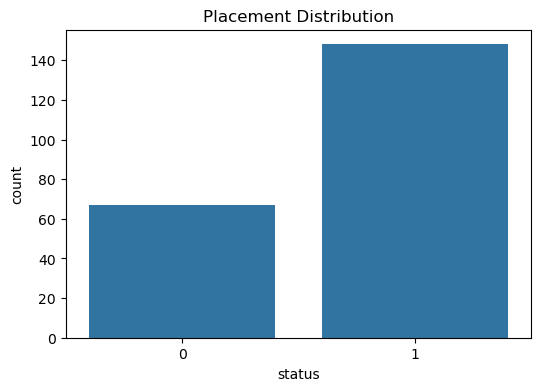

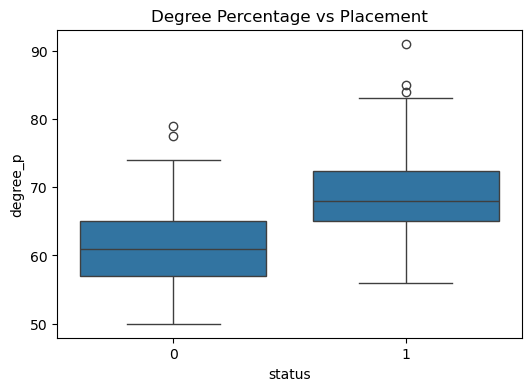


Model Accuracy: 0.813953488372093

Confusion Matrix:
[[ 6  6]
 [ 2 29]]

Feature Importance:
           Feature  Importance
1            ssc_p    0.271410
6         degree_p    0.210460
3            hsc_p    0.193035
11           mba_p    0.111244
9          etest_p    0.074267
8           workex    0.031405
10  specialisation    0.027110
5            hsc_s    0.021792
2            ssc_b    0.017435
0           gender    0.016518
7         degree_t    0.014875
4            hsc_b    0.010449


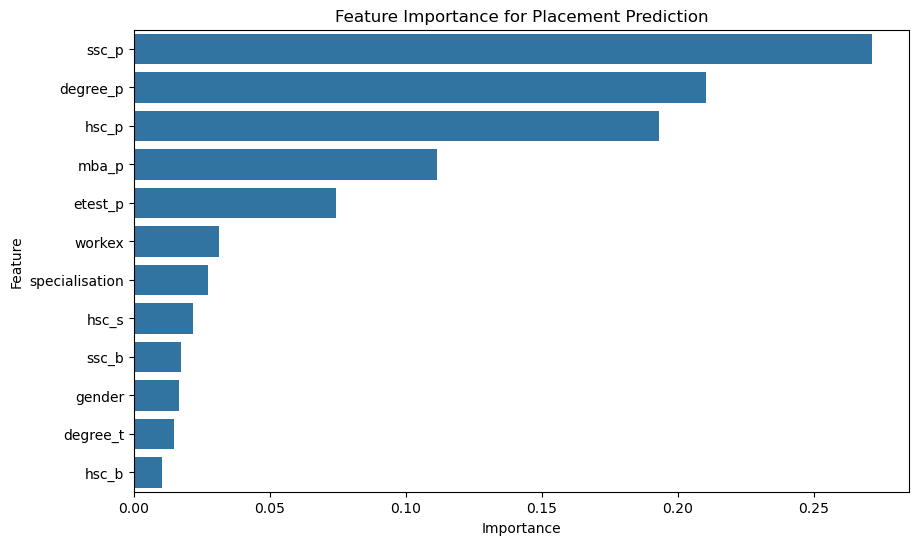


Model saved as placement_model.pkl


In [4]:
# =========================================
# 1. Import Libraries
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import pickle


# =========================================
# 2. Load Dataset (Fix tab-separated issue)
# =========================================

df = pd.read_csv("Placement_Data_Full_Class.csv")

# If dataset loaded as single column, split it
if df.shape[1] == 1:
    
    df = df[df.columns[0]].str.split("\t", expand=True)

    df.columns = [
        'sl_no','gender','ssc_p','ssc_b','hsc_p','hsc_b','hsc_s',
        'degree_p','degree_t','workex','etest_p','specialisation',
        'mba_p','status','salary'
    ]

print("First 5 Rows:")
print(df.head())


# =========================================
# 3. Convert numeric columns
# =========================================

numeric_cols = ['ssc_p','hsc_p','degree_p','etest_p','mba_p','salary']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# =========================================
# 4. Check Missing Values
# =========================================

print("\nMissing Values:")
print(df.isnull().sum())


# =========================================
# 5. Drop unnecessary columns
# =========================================

df = df.drop(columns=["sl_no","salary"], errors="ignore")


# =========================================
# 6. Encode categorical columns
# =========================================

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())


# =========================================
# 7. Visualization
# =========================================

plt.figure(figsize=(6,4))
sns.countplot(x="status", data=df)
plt.title("Placement Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="status", y="degree_p", data=df)
plt.title("Degree Percentage vs Placement")
plt.show()


# =========================================
# 8. Feature Selection
# =========================================

X = df.drop("status", axis=1)
y = df["status"]


# =========================================
# 9. Train Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================================
# 10. Train Random Forest Model
# =========================================

model = RandomForestClassifier()

model.fit(X_train, y_train)


# =========================================
# 11. Prediction
# =========================================

y_pred = model.predict(X_test)


# =========================================
# 12. Accuracy
# =========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)


# =========================================
# 13. Confusion Matrix
# =========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# =========================================
# 14. Feature Importance
# =========================================

importances = model.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)

plt.title("Feature Importance for Placement Prediction")
plt.show()


# =========================================
# 15. Save Model
# =========================================

pickle.dump(model, open("placement_model.pkl", "wb"))

print("\nModel saved as placement_model.pkl")

In [7]:
# Example Prediction (Professional Version)

import pandas as pd

sample_student = pd.DataFrame([{
    "gender":1,
    "ssc_p":75,
    "ssc_b":0,
    "hsc_p":70,
    "hsc_b":0,
    "hsc_s":2,
    "degree_p":65,
    "degree_t":2,
    "workex":1,
    "etest_p":80,
    "specialisation":0,
    "mba_p":60
}])

prediction = model.predict(sample_student)

if prediction[0] == 1:
    print("Student is likely to get PLACED")
else:
    print("Student may NOT get placed")

Student is likely to get PLACED


In [1]:
import os
os.getcwd()

'D:\\Users\\MONIKA'